In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# COGS 108 - Final Project (change this to your project's title)

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [X] YES - make available
* [ ] NO - keep private

## Link to video
https://www.youtube.com/watch?v=xQ3HPjX0av8

## Abstract

This project examines whether daily average hours of study time, extracurricular time, sleep time, social time, and physical activity are associated with GPA and self reported stress levels among the observations in our dataset. Our goal was to better understand how common lifestyle factors in students’ daily lives relate to academic performance and stress. This question was motivated by prior research cited in our project that discusses relationships between lifestyle behaviors, academic achievement, fatigue, distress, and perceived stress.

To investigate this question, we used the Student Lifestyle Dataset from Kaggle. This dataset contains 2,000 observations and 7 relevant variables: study hours, extracurricular hours, sleep hours, social hours, physical activity hours, GPA, and stress level. The dataset is described in our project materials as coming from a Google Form survey, and we cleaned and examined the data by renaming variables for readability and checking basic dataset properties such as number of observations, variable names, GPA range, and missing values. We found no missing values in the dataset, and stress level was recorded as low, moderate, or high.

In our exploratory data analysis, we described the GPA distribution as unimodal and fairly symmetric, centered around about 3.11, with a range from 2.24 to 4.0. About half of the observations fell in the high stress category, while roughly 0.35 were moderate stress and 0.15 were low stress. Correlation analysis showed that, among the variables we examined, study hours had the strongest positive relationship with GPA and were also positively associated with stress level. Sleep hours and physical activity hours were negatively correlated with stress level, while social hours showed only a weak negative relationship with stress level and extracurricular hours showed little relationship with GPA or stress level.

These findings were more consistent with some of our original expectations than with others. In this dataset, study time was the variable most strongly associated with both GPA and stress level among the variables we examined, while sleep, physical activity, and social time showed weaker relationships with stress than we originally expected. These results should be interpreted carefully because the data are self reported, primarily reflect students in India, and may not represent students in other settings. Even with these limitations, the analysis describes how these lifestyle variables relate to GPA and stress within this dataset.

## Authors

- Silas Jude: Conceptualization, Software, Visualizaton, Writing - review & editing
- Medha Nemani: Conceptualization, Background research, Project administration, Writing - original draft
- Vivian Lin: Background research, Software, Writing - original draft
- Justin Zeng: Data curation, Analysis, Experimental investigation
- Devon Cheng: Writing - original draft, Software, Methodology

## Research Question

To what degree are daily average hours of study time, extracurricular time, sleep time, social time, and physical activity predictive of an undergraduate student's GPA and self-reported stress levels?

## Background and Prior Work

Students do more than sit in classrooms listening to instructors lecture on important topics. They are proactive in their learning, socialize with diverse groups of peers, and engage in enriching activities. With the many responsibilities that come with being a student, the primary goal for most is to perform well academically, while being able to manage other aspects of their life successfully. As students, we are interested in how various personal and academic lifestyle factors can have an effect on academic standing.

Existing literature on this topic explores similar research into how personal lifestyle factors are correlated with stress level and academic standing for students. One research study exploring lifestyle factors and academic achievement found that mainly spiritual growth and living situation showed a significant positive relationship with academic achievement. <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1)

Another research study by Blasche et al. was conducted on medical students at the Medical Center of Vienna, Austria where they access the effects of academic work on students’ wellbeing, specifically fatigue, vigor, and distress. They concluded that the longer students work on a mentally demanding task, the more greater degree of fatigue and distress they face, showing positive correlations between number of hours of working on the task and fatigue/distress. <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)

Al-Roomy dives deeper specifically how stress affects academic performances, concluding that students with higher stress levels tend to achieve lower academic scores and that medical students experience higher levels of stress than nonmedical students. <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3)

While existing literature covers the relationship between student’s well being and academic achievement, our work aims at addressing the gap in literature by identifying the factor that most significantly contributes to stress level and GPA. These factors encompass various aspects of students’ lifestyle and responsibilities that shape their academic performances. As such, our topic specifically explores how number of hours sleeping, studying, participating in extracurricular activities, socializing, and doing physical activity effect stress level and GPA, if at all. We can additionally adjust for each variable in our calculations for the others, thereby addressing confounding factors.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Bakouei F, Omidvar S, Seyediandi SJ, Bakouei S. Are healthy lifestyle behaviors positively associated with the academic achievement of the university students? J Adv Med Educ Prof. 2019 Oct;7(4):224-229. doi: 10.30476/jamp.2019.74888. PMID: 31750361; PMCID: PMC6820013.
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Blasche G, Khanaqa TAK, Wagner-Menghin M. Mentally Demanding Work and Strain: Effects of Study Duration on Fatigue, Vigor, and Distress in Undergraduate Medical Students. Healthcare (Basel). 2023 Jun 7;11(12):1674. doi: 10.3390/healthcare11121674. PMID: 37372792; PMCID: PMC10298359.
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Al-Roomy M. Assessing the correlation between perceived stress and academic achievement among health sciences students. Front Med (Lausanne). 2026 Jan 9;12:1734838. doi: 10.3389/fmed.2025.1734838. PMID: 41585274; PMCID: PMC12827518.

## Hypothesis


We predict study time will be the most significant predictor of both GPA and stress levels, which tracks with the data from Al-Roomy, while sleep time will likely be positively correlated with GPA and negatively correlated with stress levels. We expect higher exercise levels, social time, and extracurricular time to be predictive of lower stress levels, which may lead to higher GPAs according to the data from Blasche et al.

## Data

### Data overview
**Dataset Name:** Student Lifestyle Dataset

**Link to the dataset:** https://www.kaggle.com/datasets/steve1215rogg/student-lifestyle-dataset 

**Number of observations:** 2000

**Number of variables:** 7

**Description of the variables most relevant to this project:**  All the variables included in this dataset are relevant to the projects, including study time, extracurricular time, sleep time, social time, physical activity, GPA, and stress levels. Time spent studying, doing extracurriculars, sleeping, socializing, and exercising are all measured in hours per day. In this dataset, data on studying time ranges from five to ten hours, extracurricular time ranges from zero to four hours, sleep time ranges from five to ten hours, socializing time ranges from zero to six hours, and physical activity time ranges from zero to thirteen hours per day. GPA is measured on a standard GPA scale from 0.0 to 4.0 with the range in this dataset being 2.24 to 4. Stress level is measured on a qualitative scale of low, moderate, or high. These variables are all relevant to the project given that our project is to determine the effect of different, common factors in students’ lives on their GPA and stress levels. These variables are relatively common for all students and therefore are fit to serve as a point of understanding correlations between said factors and GPA and stress levels for students. 

**Descriptions of any shortcomings this dataset has with respect to the project:** This dataset has some shortcomings which should be noted. First, the data is self-reported and collected through a Google form survey which may lead to inaccuracies between the data reported and the reality. While discrepancies between reported values for some variables (namely, the time reported to be spent studying, sleeping, doing extracurricular activities, exercising, and socializing) and the reality may not be big, self-reported data may be a bigger shortcoming for a variable such as stress level which is measured more subjectively in this dataset. Furthermore, this dataset comprises students primarily in India which is one country and may be not a representative sample of students in different countries. A final shortcoming of this dataset is that it is unclear whether these students are undergraduates or not and our research question aims to address undergraduate students. 

In [2]:
import sys
sys.path.append('./modules')

import get_data

datafiles = [
    { 'url': 'https://drive.google.com/uc?id=10ScFVNQaxMvGg8HrvUeBz4NSoQLMCLN8', 'filename':'student_lifestyle_dataset.csv'},
]
get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████| 1/1 [00:01<00:00,  1.53s/it]

Successfully downloaded: student_lifestyle_dataset.csv


### Student Lifestyle Dataset

This dataset is a survey styled dataset with 2,000 observations (rows) and 7 variables (columns). Each row represents one student’s response, and the dataset records how students spend time across several common activities along with two outcomes -> GPA and stress level. Because it is survey based, the values are personal estimates rather than exact measurements.

The most important metrics used in this dataset are time/use variables measured in hours/day. These include Study_Hours_Per_Day, which represents time spent doing academic work such as reading, assignments, studying; Sleep_Hours_Per_Day, representing rest and recovery; Social_Hours_Per_Day, reflecting time spent socializing; Extracurricular_Hours_Per_Day, which reflects time spent in organizations, hobbies, or other structured activities outside class; and Physical_Activity_Hours_Per_Day, which represents time spent exercising or doing fitness activities. These metrics are directly aligned with our research question since they capture how students allocate time between academics, rest, social, and other commitments.
The primary outcomes we are interested in predicting are GPA and Stress Level. GPA is a numeric measure of academic performance. Stress Level is a categorical variable that measures well being.

Because the dataset is composed of responses from a Google Form survey, there is a potential self-selection bias in which respondents are limited to individuals who are willing to participate and share information about their lifestyle and habits. Individuals who are more comfortable with self-disclosure about their lifestyle tend to be health-conscious, organized, and self-reflective, leading to overrepresentation of individuals with more “ideal” lifestyles or at least self-reported behaviors that appear more desirable. Furthermore, stress levels are not standardized, and because this variable is self-reported, respondents may interpret and report them differently based on their current beliefs, experience, or perception.

Another concern of this dataset is that the respondents are primarily from India, meaning that it reflects India’s local norms and cultural context and is not representative of students on a global scale. India is one of the many countries where the family places high expectations on students to perform well academically. As a result, respondents are more likely to report higher stress levels, and their interpretation of what constitutes “high stress levels” may differ, potentially affecting how stress is interpreted in the dataset.

Google Form surveys must be completed online through a device (computer, cell phone, etc.) and with decent internet connectivity. Those who reside in urban and more developed areas have higher accessibility to reliable connections and devices, while those who reside in rural and more remote areas lack this infrastructure, though this gap is shrinking, making this bias likely minimal but not negligible.

In [3]:
import pandas as pd
df = pd.read_csv('data/00-raw/student_lifestyle_dataset.csv')
df.rename(columns={'Student_ID': 'student id',
                   'Study_Hours_Per_Day': 'study hours',
                   'Extracurricular_Hours_Per_Day': 'extracurricular hours',
                   'Sleep_Hours_Per_Day': 'sleep hours',
                   'Social_Hours_Per_Day': 'social hours',
                   'Physical_Activity_Hours_Per_Day': 'physical activity hours',
                   'Stress_Level': 'stress level',
                   'GPA': 'gpa'
                   }, inplace=True)
df.head()

,student id,study hours,extracurricular hours,sleep hours,social hours,physical activity hours,gpa,stress level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [4]:
print(f"Total number of missing values in the dataset: {df.isna().sum().sum()}")
print(f"Variables: {df.columns.tolist()[1:]}; length: {len(df.columns.tolist()[1:])}")
print(f"Potential values for stress levels: {df['stress level'].unique()}")
print(f"GPA range: [{df['gpa'].min()}, {df['gpa'].max()}]")
print(f"Number of observations: {df.shape[0]}")
df.describe()

Total number of missing values in the dataset: 0
Variables: ['study hours', 'extracurricular hours', 'sleep hours', 'social hours', 'physical activity hours', 'gpa', 'stress level']; length: 7
Potential values for stress levels: ['Moderate' 'Low' 'High']
GPA range: [2.24, 4.0]
Number of observations: 2000


,student id,study hours,extracurricular hours,sleep hours,social hours,physical activity hours,gpa
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


## Results

### Exploratory Data Analysis

In [5]:
df = pd.read_csv('data/00-raw/student_lifestyle_dataset.csv')
df.rename(columns={'Student_ID': 'student id',
                   'Study_Hours_Per_Day': 'study hours',
                   'Extracurricular_Hours_Per_Day': 'extracurricular hours',
                   'Sleep_Hours_Per_Day': 'sleep hours',
                   'Social_Hours_Per_Day': 'social hours',
                   'Physical_Activity_Hours_Per_Day': 'physical activity hours',
                   'Stress_Level': 'stress level',
                   'GPA': 'gpa'
                   }, inplace=True)

#### Let's look at the distribution of some of the variables

In [6]:
fig = px.histogram(
    df,
    x='gpa',
    title='GPA distribution',
    width=800,
    height=600
)
fig.update_traces(
    xbins={'start':2,'end':4,'size':0.25}
)
fig.update_layout(
    xaxis_title='GPA',
    yaxis_title='frequency'
)
fig.show()

The distribution for GPA is unimodal and fairly symmetric. The majority of the datapoints are within the 3.0 to 3.24 range with the center around 3.11 and the range is from 2.24 to 4.0 

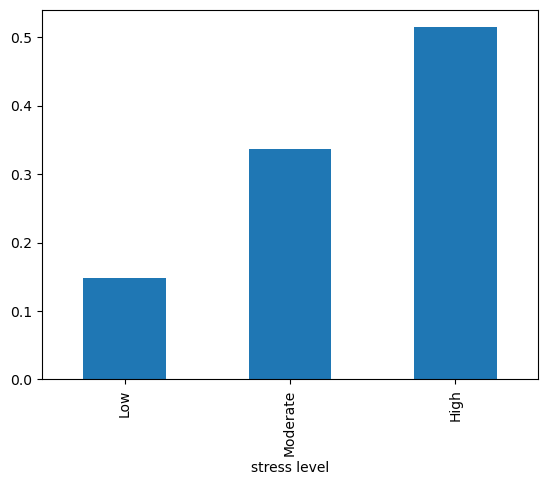

In [7]:
df['stress level'].value_counts(normalize=True, ascending=True).plot.bar();

About half of the data points are in the high stress level category, with the proportion of the data in the moderate stress level is about 0.35 and, and the proportion of the data in the low stress level category is about 0.15. 

### Now we can examine correlation between variables

In [8]:
fig = px.scatter(df, x='study hours', y='gpa')
fig.show()

Looks very linear!

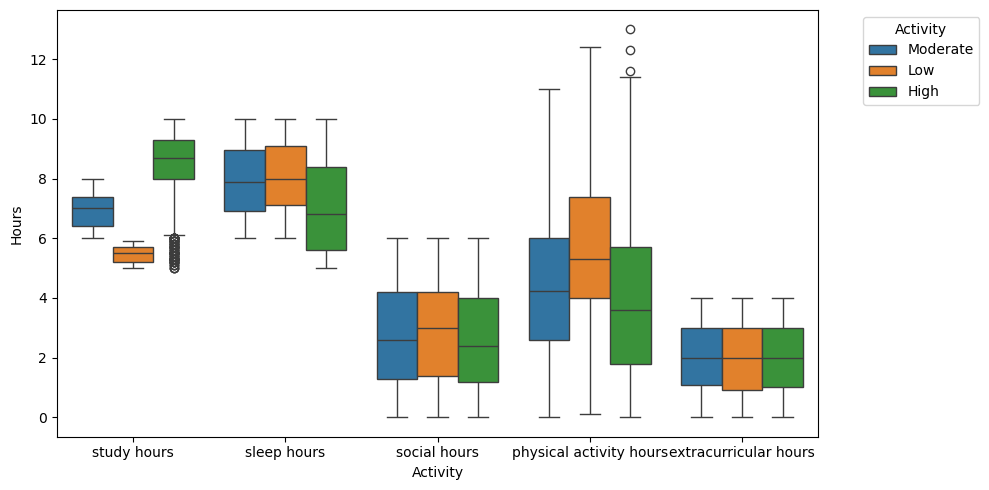

In [9]:
lifestyle = df.melt(
   id_vars='stress level',
   value_vars=['study hours', 'sleep hours', 'social hours', 'physical activity hours', 'extracurricular hours'],
   var_name='Activity',
   value_name='Hours'
)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Activity', y='Hours', hue='stress level', data=lifestyle)
plt.legend(title='Activity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- **Study Hours:** Although there is a positive correlation between study hours and stress level, the same correlation applies to the variance and standard deviation of study hours and stress levels. Specifically, high stress levels can be explained by students not studying enough and therefore not fully understanding the content, or the material being difficult, so that no matter how long they are studying for, they are still not comprehending it.
- **Extracurricular Hours:** Extracurricular hours have little effect on stress level, and there is little difference in the variance and standard deviation among each category of stress level.
- **Sleep Hours:** High stress levels have the largest variance/standard deviation. This is due to the fact that sleep hours and GPA are negatively correlated, and a lower GPA equals more stress. On the contrary, not sleeping enough means that students will be more stressed because it interferes with their learning and ability to stay functional.
- **Social Hours:** Social hours do not have a significant impact on stress levels, but they are negatively correlated with each other. Humans are social beings, and having a support system and socializing has been proven to reduce stress.
- **Physical Activity Hours:** Physical activity hours and stress levels are negatively correlated. Exercising reduces stress hormones while boosting mood, energy, and ability to sleep.


/var/folders/2k/1mn4pz950vd0j2x262dkkkwc0000gn/T/ipykernel_48307/1029423939.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



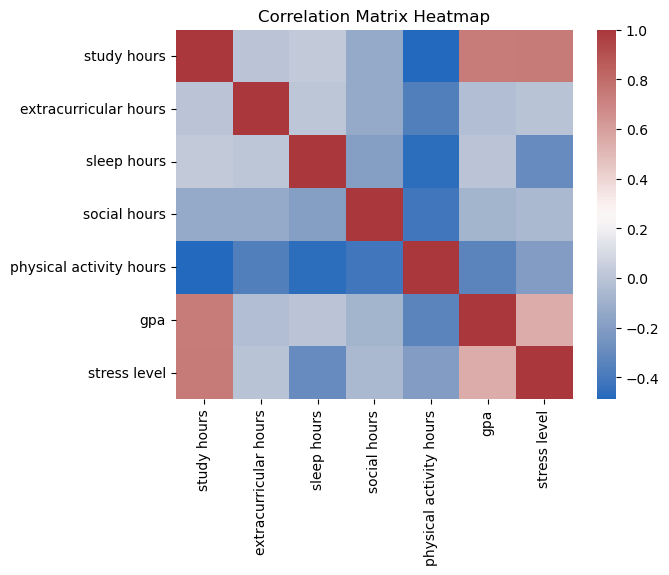

,study hours,extracurricular hours,sleep hours,social hours,physical activity hours,gpa,stress level
study hours,1.000000,-0.002629,0.026717,-0.137820,-0.488113,0.734468,0.738843
extracurricular hours,-0.002629,1.000000,0.008844,-0.139081,-0.369989,-0.032174,-0.006099
sleep hours,0.026717,0.008844,1.000000,-0.193556,-0.470302,-0.004278,-0.298917
social hours,-0.137820,-0.139081,-0.193556,1.000000,-0.417142,-0.085677,-0.054702
physical activity hours,-0.488113,-0.369989,-0.470302,-0.417142,1.000000,-0.341152,-0.205207
gpa,0.734468,-0.032174,-0.004278,-0.085677,-0.341152,1.000000,0.550395
stress level,0.738843,-0.006099,-0.298917,-0.054702,-0.205207,0.550395,1.000000


In [10]:
num = df.copy()
num['stress level'] = num['stress level'].replace({'Low': 0, 'Moderate': 1, 'High': 2})
corr = num.drop(columns=['student id']).corr()
sns.heatmap(corr, cmap='vlag')
plt.title('Correlation Matrix Heatmap')
plt.show()
corr

This pairplot shows that most of the lifestyle factors in our dataset (namely, extracurricular hours, physical activity hours, sleep hours, and social hours) are generally negatively correlated with GPA and stress level. All of the lifestyle factors are negatively correlated with each other with makes sense because students have only a limited amount of hours to devote to various activities per week. Only study hours was positively correlated with GPA and a high stress level, with study hours having a fairly strong correlation of 0.734468 with GPA and 0.738843 with high stress level. Other noteworthy points of this plot include sleep hours being somewhat weakly negatively correlated with stress level with a coefficient of -0.298917 and physical activity hours also being  somewhat weakly negatively correlated with stress level with a coefficient of -0.205207. Social hours was quite weakly correlated with stress level with a coefficient of -0.054702. All three of these correlations were not necessarily strong support of our hypothesis that sleep hours, physical activity hours, and social hours would be more strongly indicative of lower stress levels. 

### GPA Regression

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.  Every project will be different here... but some examples of analyses are: inferential statistics where you calculate p-values (like a t-test or a Monte Carlo simulation), regression models, or a machine learning model

**NOTE** The final report should not be overly long.  If this analysis step is huge and complicated  and you went down a lot of dead ends, then you should do something about that.  Some options... 

1) remove any analysis you later decided was unecessary side quest before checking in for the final hand in
2) if the code to do an analysis is very long (in either lines or in time to compute) put it in a different file.  In that file make write out results of analysis into `results/` and reload the results here instead of recalculating it. And make a statement here like "To see the code responsible for analyses see `path/to/some-file-name.ipynb_or.py`."

**First, I'll test a simple linear regression for gpa with study hours as the X variable.**

In [11]:
# Train-test split for cross-validation
X_train, X_test, y_train, y_test = train_test_split(df[['study hours']], df['gpa'], test_size=0.25, random_state=67)

linreg = LinearRegression()
linreg.fit(X_train, y_train)
linreg_scores = cross_val_score(linreg, X_test, y_test, scoring='neg_root_mean_squared_error')
print(linreg_scores)
print(f'mean score: {linreg_scores.mean()}')

[-0.21064032 -0.21215129 -0.1702798  -0.20679467 -0.19327073]
mean score: -0.19862736071427906


**I'll now test the addition of the next most highly correlated predictor variable, physical activity hours.**

In [12]:
# Train-test split for cross-validation
X_train, X_test, y_train, y_test = train_test_split(df[['study hours', 'physical activity hours']], df['gpa'], test_size=0.25, random_state=67)

linreg = LinearRegression()
linreg.fit(X_train, y_train)
linreg_scores = cross_val_score(linreg, X_test, y_test, scoring='neg_root_mean_squared_error')
print(linreg_scores)
print(f'mean score: {linreg_scores.mean()}')

[-0.21064284 -0.21335112 -0.17058843 -0.20883684 -0.19347329]
mean score: -0.19937850477561914


**This had almost no effect on the score, so I won't use that variable. I also tried the inclusion of other variables, but they seem to have similar or smaller effects, so we will stick with the simple linear model.**

In [13]:
# Train-test split for cross-validation
X_train, X_test, y_train, y_test = train_test_split(df[['study hours']], df['gpa'], test_size=0.25, random_state=67)

linreg = LinearRegression()
linreg.fit(X_train, y_train)
linreg_scores = cross_val_score(linreg, X_test, y_test, scoring='neg_root_mean_squared_error')
df['predicted_gpa']=linreg.predict(df[['study hours']])
df.head(10)

,student id,study hours,extracurricular hours,sleep hours,social hours,physical activity hours,gpa,stress level,predicted_gpa
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,3.027172
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,2.782646
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,2.752080
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,2.966040
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,3.210566
5,6,6.0,2.1,8.0,0.3,7.6,2.85,Moderate,2.889626
6,7,8.0,0.7,5.3,5.7,4.3,3.08,High,3.195283
7,8,8.4,1.8,5.6,3.0,5.2,3.20,High,3.256415
8,9,5.2,3.6,6.3,4.0,4.9,2.82,Low,2.767363
9,10,7.7,0.7,9.8,4.5,1.3,2.76,Moderate,3.149435


### Stress Level Classification

Features:
- study hours
- extracurricular hours
- sleep hours
- social hours
- physical activity hours
- gpa

Dependent Variable: stress level

Classification Model Type: `DecisionTreeClassifier`

**Train:** 70% of data --> X_train, y_train

What is used to train the model



**Validation:** 15% of data --> X_val, y_val

What is used to improve the model (tuning hyperparameters)



**Test:** 15% of data --> X_test, y_test

What is used to see how the model performs on unseen data

In [14]:
# Features and target
features = ['study hours', 'gpa', 'extracurricular hours',
            'sleep hours', 'social hours', 'physical activity hours']

X = df[features]
y = df['stress level']

# Train / validation / test split
X_train, X_eval, y_train, y_eval = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_eval, y_eval, test_size=0.5, random_state=42)

highest_score = 0
best_feature = None

for feature in features:

    model = DecisionTreeClassifier()
    model.fit(X_train[[feature]], y_train)

    y_pred = model.predict(X_val[[feature]])
    val_f1 = f1_score(y_val, y_pred, average='weighted')

    print(f"{feature}: {val_f1}")

    if val_f1 > highest_score:
        highest_score = val_f1
        best_feature = feature

print("Best first feature:", best_feature)

study hours: 0.8592828090035541
gpa: 0.589819106194715
extracurricular hours: 0.3831694987514465
sleep hours: 0.4979805825242718
social hours: 0.4029642000992366
physical activity hours: 0.42202915681639086
Best first feature: study hours


In [15]:
second_features = ['gpa', 'extracurricular hours', 'sleep hours',
                   'social hours', 'physical activity hours']

sec_best_feature = None
highest_score_2 = 0

for col in second_features:

    X_train_cols = X_train[[best_feature, col]]
    X_val_cols = X_val[[best_feature, col]]

    stress_decision_tree_classifier = DecisionTreeClassifier()
    stress_decision_tree_classifier.fit(X_train_cols, y_train)

    y_pred = stress_decision_tree_classifier.predict(X_val_cols)
    val_f1 = f1_score(y_val, y_pred, average='weighted')

    print(f'{best_feature} + {col}: {val_f1}')

    if val_f1 > highest_score_2:
        highest_score_2 = val_f1
        sec_best_feature = col

print(f'Two best features: "{best_feature}" and "{sec_best_feature}"')

study hours + gpa: 0.810436315290461
study hours + extracurricular hours: 0.8003552340767531
study hours + sleep hours: 1.0
study hours + social hours: 0.7883981719215364
study hours + physical activity hours: 0.8500638379777156
Two best features: "study hours" and "sleep hours"


In [16]:
# Evaluation
X_train_best_feat = X_train[[best_feature, sec_best_feature]]
X_val_best_feat = X_val[[best_feature, sec_best_feature]]
X_test_best_feat = X_test[[best_feature, sec_best_feature]]

stress_decision_tree_classifier = DecisionTreeClassifier()
stress_decision_tree_classifier.fit(X_train_best_feat, y_train)

# Predict on test set
y_test_pred = stress_decision_tree_classifier.predict(X_test_best_feat)

# Compute F1 score
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("Test F1 Score:", test_f1)

Test F1 Score: 1.0


The minimum number of features that optimizes model performance is two: `study hours` and `sleep hours`, achieving an F1-score of 1.0 on both the validation and test sets. Since the model already achieves perfect performance, hyperparameter tuning does not improve the results further. This near-perfect performance is likely due to the strong predictive power of these features, which clearly separate the target classes, rather than model complexity.

# Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> We don't know how much/little information was given to subjects. There was at least some degree of consent as all subjects did submit a form, but we can't know whether they knew what the information would be used for.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> This is a specific subset of students (those who have gone through the Indian school system) due to the source of the data, which may not be perfectly representative of students in other countries. However, there's not much to be done about that without gathering our own data, so we just need to be mindful of this fact with the conclusions that we draw.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> This has been done, all subjects are given anonymized ID numbers and names/actual identification information is not included.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
 
> The data used does not include any information on the individual respondents, so there is no way for us to know the distribution of various protected statuses, but we are certainly not basing our calculations on those factors.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> We do not control the data, all data has been and will continue to be publicly available.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> See **B.1**.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> See **B.1**.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> When writing our analysis, we'll be able to address blindspots by engaging with existing literature about the subject and therefore covering our blindspots through analysis and conclusions determined by subject matter experts. 

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> See **A.2**.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> Yes.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> Data is anonymized, there is no PII in any of it.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

 > Yes, every part of the code is represented and explained.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> None of these are directly discriminatory, and while you could make an argument that several of them are somewhat related to sensitive variables, it's all in somewhat indirect ways and none could be considered actual proxies.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> We do not have information on the individuals in the data and therefore cannot determine this.

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> We tried to keep our metrics as "raw" as possible. That is to say, we are avoiding using proxies to minimize the effects of confounding variables and prevent optimization for those metrics from becoming less representative of what we are attempting to measure. GPA is a widely accepted standard for measuring academic performance and should be representative of it. Self-reported stress levels are the most unbiased way to measure stress we could think of.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

> There is no decision model, there's nothing to justify. We simply performed data analysis.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> See **D.4**.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

> This is not a predictive model; rather we are examining whether a true predictive model *could* use these variables. It is not intended to be used as replacement for evaluating actual GPA or stress, for instance. The dataset it will be used on is constant, therefore none of these deployment considerations are particularly relevant.

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

> See **E.1**. This project is not intended to be used as a basis for decision making, rather it is simple observation.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

> There is no model being produced.

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> See **E.3**.

## Discusison and Conclusion

Our results, beginning with our exploratory data analysis, showed that study hours had the strongest positive correlation with GPA as well as stress level while the other lifestyle factors (physical activity hours, extracurricular hours, sleep hours, social hours) are generally negatively correlated with GPA and stress level. This was consistent with our hypothesis and what we found in our background research referring to previously done studies on similar topics of how student lifestyle affects academic performance and stress levels. 

Specifically, our results were consistent with a study that found that longer study hours are associated with higher levels of stress. However, we also found that study hours is positively correlated with GPA, while our background research suggests that the opposite could also be true where a longer amount of time spent studying could contribute to poor academic performance due to factors like stress, burn out, etc. These contradictory results might be clarified in further research that goes beyond the limitations of this work. 

Other noteworthy results from our analysis include the finding that social, extracurricular, and physical activity hours were rather weakly negatively correlated with stress levels which was inconsistent with our hypothesis that these factors would be strong indicators of lower stress levels. We also saw that the lifestyle factors were all negatively correlated with each other which follows the reasoning that if more time is spent with a certain activity, the amount of time spent in another activity would go down. From this we learned that trends in academic performance and stress level could be associated with not just certain lifestyle factors but also how students are dividing their time between these different activities. 

In addition to the exploratory analysis and GPA linear regression, we trained a classification model to predict stress levels based on student lifestyle factors. The features that best predicted stress levels were study hours and sleep hours combined with an F-1 score of 1.0 on the train and test set, showing that together, they are the best predictors of stress levels. These results are consistent with what is shown in the EDA boxplot, where there are noticeable correlations between the number of hours spent on studying or sleeping and stress levels. 

Expanding on limitations, while our dataset encompasses 2000 datapoints, these data originate only from students in India and are obtained via a Google Form survey. The self-reported nature of this data introduces possible biases and room for incorrect measurements of data. Furthermore, it’s possible that along with data collected in different places may be different, data collected from different academic levels (high school, undergraduate, graduate, medical students, etc) might result in different data. 

Next steps in research could expand data collection to different and more locations to account for differences by geographical regions such as economic factors, cultural differences, etc. Additionally, the method of measurement in future research could move away from self-reported data and towards methods that introduce less room for bias. For example, for health-related lifestyle factors, health and fitness-tracking technology could be used for participants involved in the studies. 
